# Matplotlib Visualizations Using the Software Companies Dataset

This notebook contains **10 beginner-friendly Matplotlib visualizations**.

Each example:
- Uses the supplied CSV dataset.
- Includes a short explanation.
- Uses simple Pandas and Matplotlib code.
- Can be executed independently after running the setup cells.

## 1. Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# The CSV file should be in the same folder as this notebook.
csv_file = Path("software_companies_dataset_v2.csv")

if not csv_file.exists():
    raise FileNotFoundError(
        f"{csv_file} was not found. Place the CSV file in the same folder as the notebook."
    )

df = pd.read_csv(csv_file)

# Convert date columns to datetime format.
df["Incorporation_Date"] = pd.to_datetime(df["Incorporation_Date"], errors="coerce")
df["Last_Funding_Date"] = pd.to_datetime(df["Last_Funding_Date"], errors="coerce")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 25)


,Company_ID,Company_Name,Industry,Headquarters_City,Country,Ownership_Type,Customer_Segment,Primary_Cloud,Risk_Rating,Year_Founded,Incorporation_Date,Last_Funding_Date,Employees,Annual_Revenue,Profit_Margin,Market_Share,Product_Lines,R&D_Spending,Average_Salary,Training_Hours_Per_Employee,Employee_Satisfaction,Adoption_Rate_AI,Adoption_Rate_Cloud,Adoption_Rate_Blockchain,CEO_Tenure_Years
0,807869,Neo Soft 760,HealthTech,Pune,Australia,Private,SME,Azure,Medium,2023,2023-07-15,2025-07-24,44377.0,7.299762e+07,17.16,33.16,16,3959494.45,3223371.94,90.7,3.99,27.47,78.25,24.77,5
1,985270,Next Analytics 229,Gaming,Noida,UAE,Startup,B2B2C,GCP,Low,2013,2013-09-17,2023-02-25,3418.0,5.997070e+07,3.39,11.87,1,4483284.44,3440809.32,77.9,3.01,68.36,33.88,53.10,13
2,615066,Innova Works 693,Cybersecurity,Chennai,Germany,Startup,B2B,IBM Cloud,Medium,1999,1999-02-01,2004-01-08,3847.0,1.146540e+08,6.08,25.40,22,26299168.52,3411320.38,93.8,3.11,71.59,62.58,53.26,16
3,756196,Secure Labs 605,Cybersecurity,Noida,UK,Public,SME,GCP,Low,1992,1992-06-18,1997-03-05,47932.0,4.802480e+07,26.06,18.90,2,9575493.89,2329426.44,42.3,3.51,61.48,74.21,22.90,1
4,292453,Logic Systems 31,Cloud Services,NaN,UAE,Private,B2B2C,AWS,Medium,2005,2005-10-20,NaT,13768.0,1.851525e+08,36.95,2.22,3,30870883.91,1266740.76,90.2,4.94,13.24,93.77,36.81,13


## Dataset Overview

Before creating charts, review the column names, data types, and missing values.

In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Columns:
['Company_ID', 'Company_Name', 'Industry', 'Headquarters_City', 'Country', 'Ownership_Type', 'Customer_Segment', 'Primary_Cloud', 'Risk_Rating', 'Year_Founded', 'Incorporation_Date', 'Last_Funding_Date', 'Employees', 'Annual_Revenue', 'Profit_Margin', 'Market_Share', 'Product_Lines', 'R&D_Spending', 'Average_Salary', 'Training_Hours_Per_Employee', 'Employee_Satisfaction', 'Adoption_Rate_AI', 'Adoption_Rate_Cloud', 'Adoption_Rate_Blockchain', 'CEO_Tenure_Years']

Data types:
Company_ID                              int64
Company_Name                           object
Industry                               object
Headquarters_City                      object
Country                                object
Ownership_Type                         object
Customer_Segment                       object
Primary_Cloud                          object
Risk_Rating                            object
Year_Founded                            int64
Incorporation_Date             datetime64[ns]
Last_F

## Visualization 1: Bar Chart — Number of Companies by Industry

A bar chart is useful for comparing counts across categories.  
This chart shows how many companies belong to each industry.

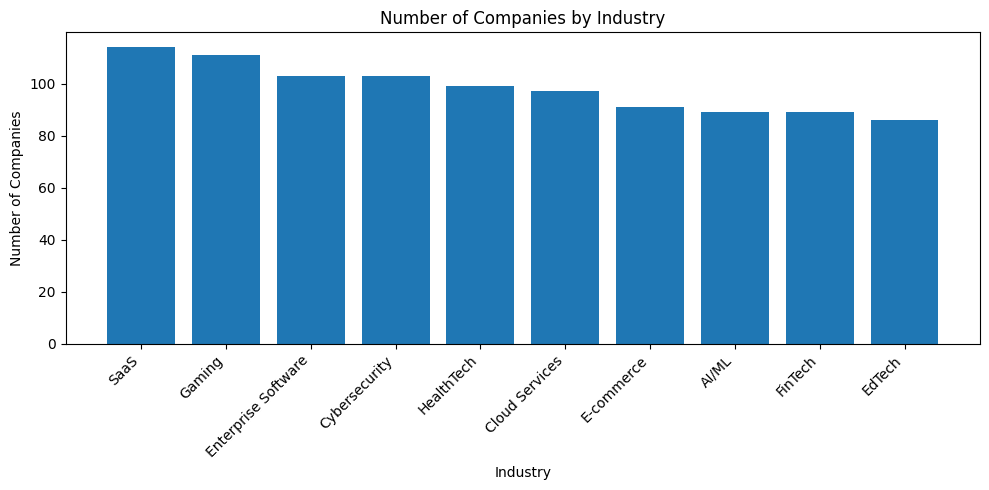

In [3]:
industry_counts = df["Industry"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(industry_counts.index, industry_counts.values)
plt.title("Number of Companies by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Companies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Visualization 2: Horizontal Bar Chart — Top 10 Countries

A horizontal bar chart is helpful when category names are easier to read vertically.  
This example displays the ten countries with the highest number of companies.

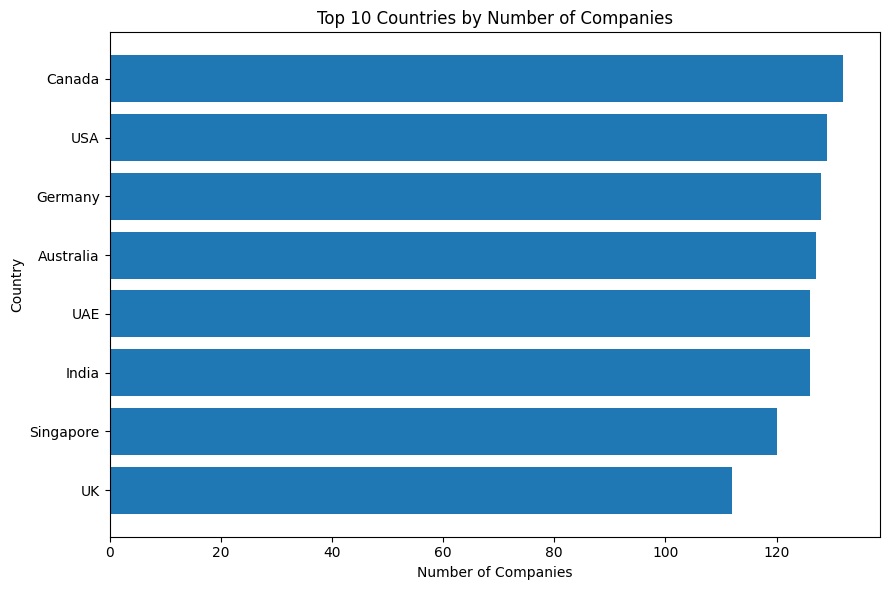

In [4]:
country_counts = df["Country"].value_counts().head(10).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(country_counts.index, country_counts.values)
plt.title("Top 10 Countries by Number of Companies")
plt.xlabel("Number of Companies")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## Visualization 3: Pie Chart — Ownership Type Distribution

A pie chart shows how a whole is divided among a small number of categories.  
Here, it displays the percentage share of each ownership type.

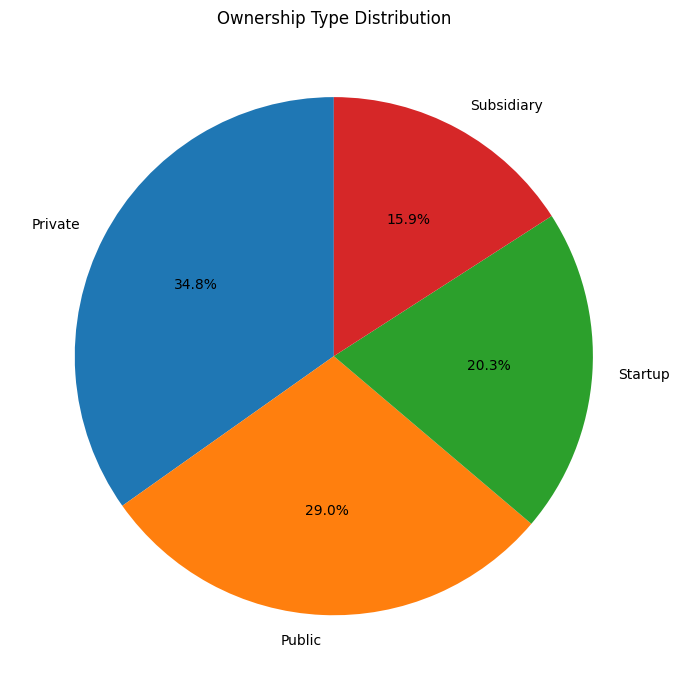

In [5]:
ownership_counts = df["Ownership_Type"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    ownership_counts.values,
    labels=ownership_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Ownership Type Distribution")
plt.tight_layout()
plt.show()

## Visualization 4: Histogram — Annual Revenue Distribution

A histogram shows the distribution of a numerical column.  
This chart helps us see how annual revenue values are spread across companies.

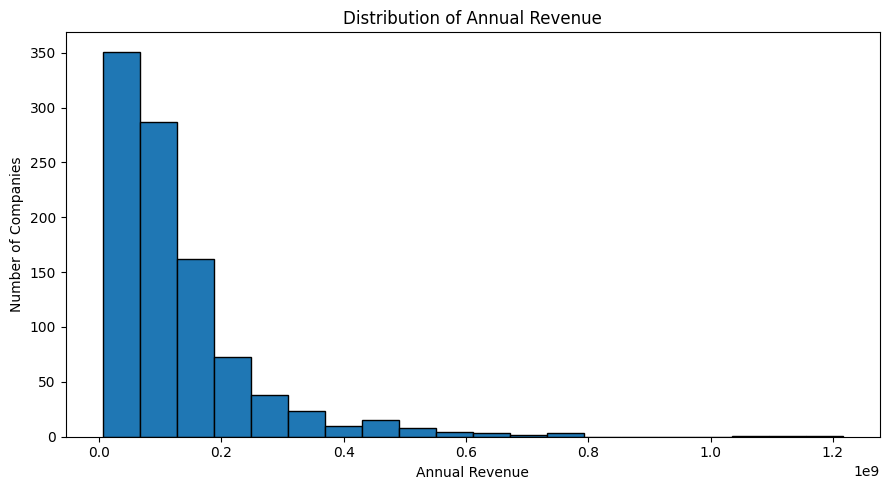

In [6]:
revenue = df["Annual_Revenue"].dropna()

plt.figure(figsize=(9, 5))
plt.hist(revenue, bins=20, edgecolor="black")
plt.title("Distribution of Annual Revenue")
plt.xlabel("Annual Revenue")
plt.ylabel("Number of Companies")
plt.tight_layout()
plt.show()

## Visualization 5: Box Plot — Profit Margin

A box plot summarizes the median, spread, and possible outliers.  
This example gives a quick view of the profit margin distribution.

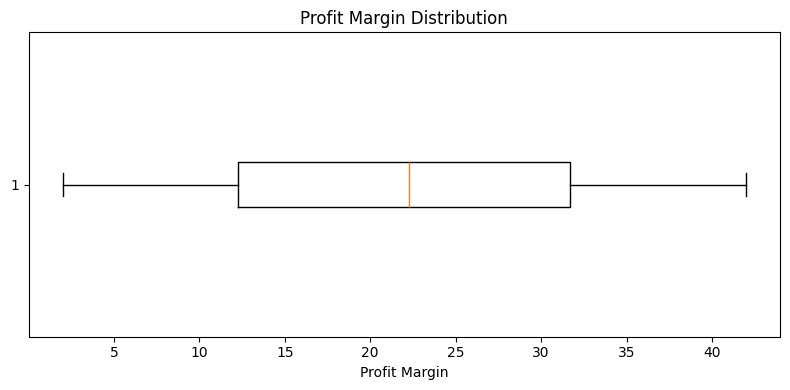

In [7]:
profit_margin = df["Profit_Margin"].dropna()

plt.figure(figsize=(8, 4))
plt.boxplot(profit_margin, vert=False)
plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin")
plt.tight_layout()
plt.show()

## Visualization 6: Scatter Plot — Employees vs Annual Revenue

A scatter plot helps examine the relationship between two numerical variables.  
Each point represents one company.

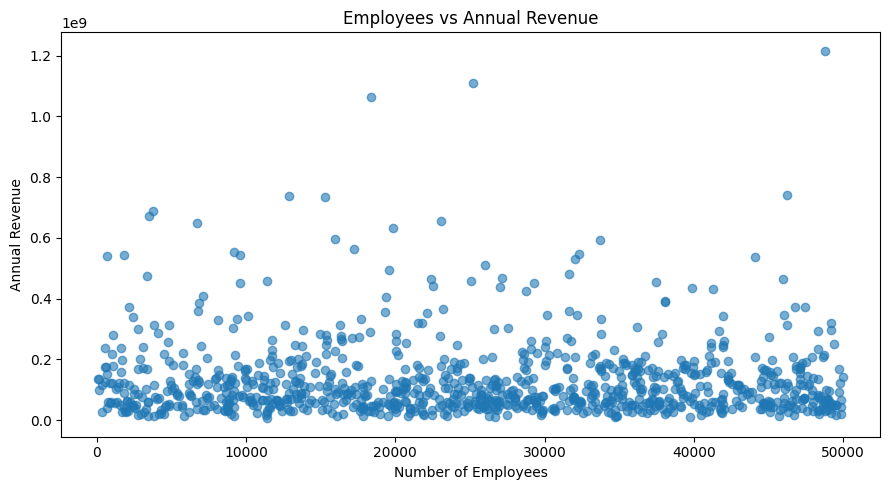

In [8]:
plot_data = df[["Employees", "Annual_Revenue"]].dropna()

plt.figure(figsize=(9, 5))
plt.scatter(plot_data["Employees"], plot_data["Annual_Revenue"], alpha=0.6)
plt.title("Employees vs Annual Revenue")
plt.xlabel("Number of Employees")
plt.ylabel("Annual Revenue")
plt.tight_layout()
plt.show()

## Visualization 7: Line Chart — Average Revenue by Founding Year

A line chart is useful for showing change across an ordered variable.  
The chart groups companies by founding year and plots their average annual revenue.

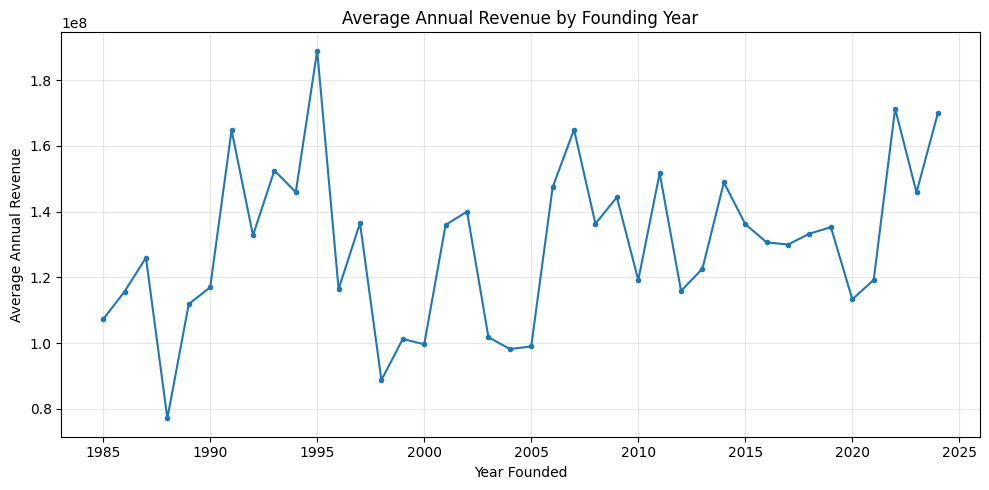

In [9]:
yearly_revenue = (
    df.groupby("Year_Founded")["Annual_Revenue"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(yearly_revenue.index, yearly_revenue.values, marker="o", markersize=3)
plt.title("Average Annual Revenue by Founding Year")
plt.xlabel("Year Founded")
plt.ylabel("Average Annual Revenue")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization 8: Grouped Bar Chart — Average AI and Cloud Adoption by Industry

A grouped bar chart compares multiple measurements across categories.  
This example compares average AI adoption and cloud adoption for each industry.

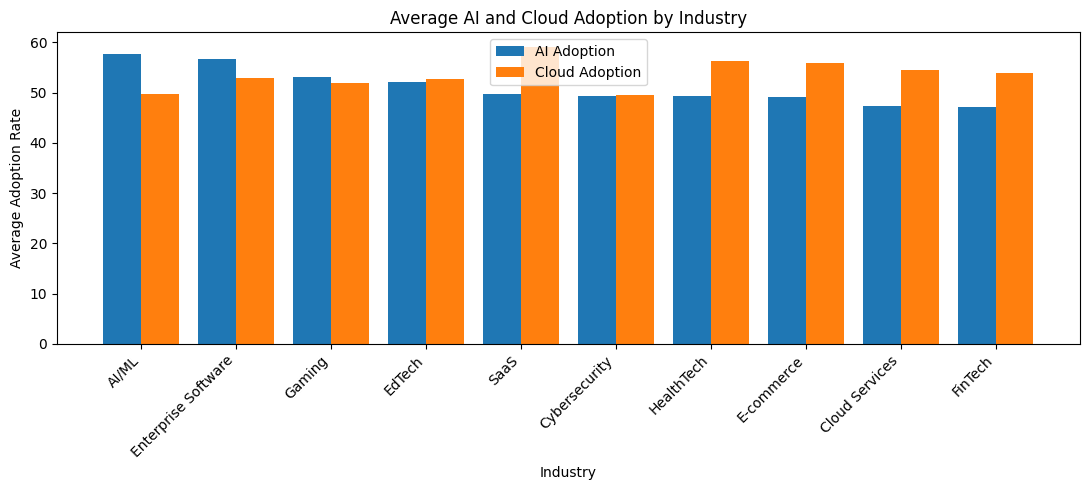

In [10]:
adoption_by_industry = (
    df.groupby("Industry")[["Adoption_Rate_AI", "Adoption_Rate_Cloud"]]
      .mean()
      .sort_values("Adoption_Rate_AI", ascending=False)
)

x = range(len(adoption_by_industry))
width = 0.4

plt.figure(figsize=(11, 5))
plt.bar(
    [i - width / 2 for i in x],
    adoption_by_industry["Adoption_Rate_AI"],
    width=width,
    label="AI Adoption"
)
plt.bar(
    [i + width / 2 for i in x],
    adoption_by_industry["Adoption_Rate_Cloud"],
    width=width,
    label="Cloud Adoption"
)

plt.title("Average AI and Cloud Adoption by Industry")
plt.xlabel("Industry")
plt.ylabel("Average Adoption Rate")
plt.xticks(list(x), adoption_by_industry.index, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Visualization 9: Stacked Bar Chart — Risk Rating by Customer Segment

A stacked bar chart shows both the total and the composition of each category.  
This chart shows risk-rating counts within each customer segment.

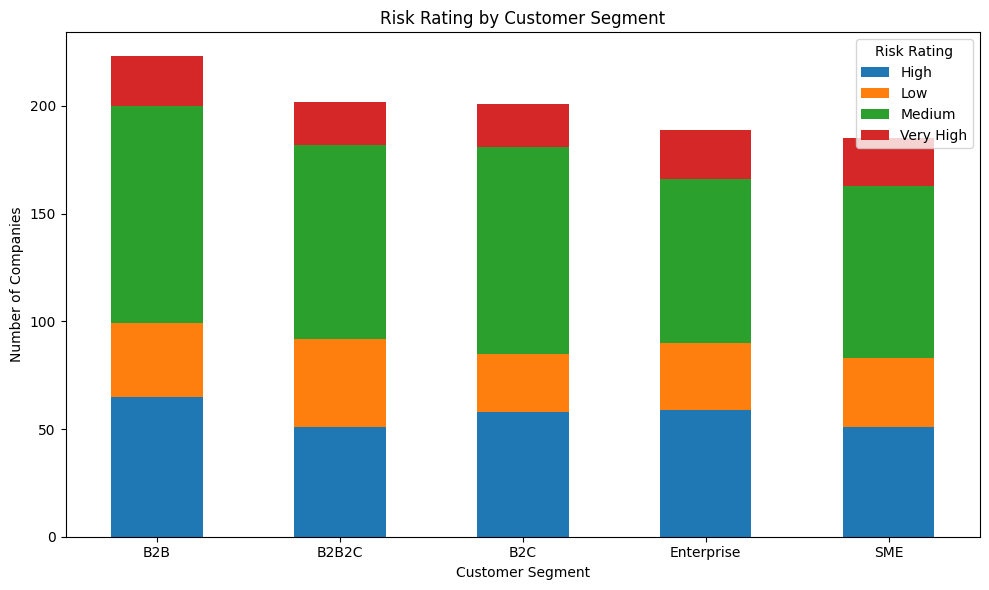

In [11]:
risk_segment = pd.crosstab(df["Customer_Segment"], df["Risk_Rating"])

risk_segment.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.title("Risk Rating by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Companies")
plt.xticks(rotation=0)
plt.legend(title="Risk Rating")
plt.tight_layout()
plt.show()

## Visualization 10: Area Chart — Average Training Hours by CEO Tenure

An area chart is similar to a line chart, but the area below the line is filled.  
This example shows average employee training hours for different CEO tenure values.

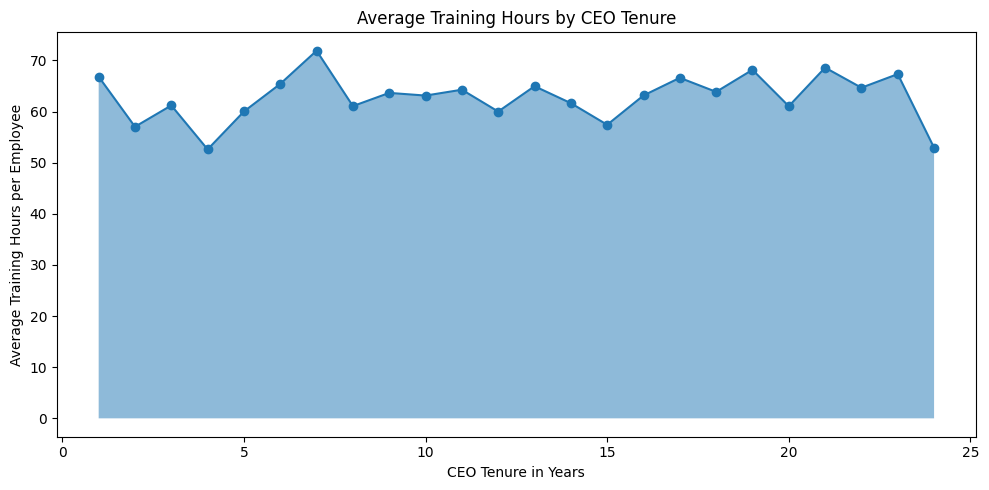

In [12]:
training_by_tenure = (
    df.groupby("CEO_Tenure_Years")["Training_Hours_Per_Employee"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(10, 5))
plt.fill_between(
    training_by_tenure.index,
    training_by_tenure.values,
    alpha=0.5
)
plt.plot(training_by_tenure.index, training_by_tenure.values, marker="o")
plt.title("Average Training Hours by CEO Tenure")
plt.xlabel("CEO Tenure in Years")
plt.ylabel("Average Training Hours per Employee")
plt.tight_layout()
plt.show()

## Conclusion

You created ten simple Matplotlib visualizations:

1. Bar chart  
2. Horizontal bar chart  
3. Pie chart  
4. Histogram  
5. Box plot  
6. Scatter plot  
7. Line chart  
8. Grouped bar chart  
9. Stacked bar chart  
10. Area chart